# Does the engulfing candle actually call the turn? 🕯️
### The most-taught reversal pattern, measured honestly — in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

Open any charting app and you'll meet the **engulfing candle**. The story is irresistible: a small red (down) day, then a big green (up) day whose body completely **engulfs** the day before — "the buyers just took over, the bottom is in, **go long**." Flip the colours for a **bearish** engulfing: a top is in, **go short**. It's the first reversal every beginner learns.

So we did the obvious thing nobody seems to do: found **every** engulfing candle on 30 big, liquid US stocks over 21 years, bought (or shorted) the next morning exactly as the textbook says, and asked — *did the reversal happen?*

The answer is worse than "no." The pattern points the **wrong way**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Fixed **30-name** basket (29 large-caps + **SPY**, names still trading today). That carries **survivorship** — but here it *helps* the bullish-reversal claim, and the pattern still fails. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from engulfing_pattern import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real(allow_fetch=False) if HAVE_REAL else None
print("real engulfing cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'fp': 'bf1d6cb7ca54', 'n_names': 30, 'n_events': 12144, 'n_bull': 5736, 'n_bear': 6408, 'h1': (1, 12144, -0.049, 0.028, 48.1, -3.79, -3.89, 1.0, -0.15), 'h3': (3, 12143, -0.114, 0.141, 48.2, -5.14, -4.85, 1.0, -0.217), 'h5': (5, 12140, -0.174, 0.253, 48.2, -5.74, -5.61, 1.0, -0.279), 'h10': (10, 12127, -0.176, 0.53, 48.3, -4.25, -4.08, 1.0, -0.285), 'bull': {1: (-0.011, -0.59, 49.7), 3: (0.072, 2.24, 52.1), 5: (0.13, 2.92, 53.5), 10: (0.456, 6.9, 55.9)}, 'bear': {1: (-0.083, -4.55, 46.7), 3: (-0.281, -8.76, 44.7), 5: (-0.446, -10.46, 43.6), 10: (-0.741, -11.92, 41.6)}, 'myth': [('plain', 12144, -0.049, -3.79, 48.1), ('+downtrend', 5124, -0.052, -2.73, 47.6), ('+volume spike', 975, -0.11, -1.91, 47.4), ('+both', 405, -0.135, -1.4, 47.9)], 'syn': [(0.0, 16295, 0.009, 0.9, 0.188, 50), (0.004, 15263, 0.4, 38.77, 0.0, 62)]}


real engulfing cache present: True | names: 30


## The answer first

| Question | Answer |
|---|---|
| After an engulfing, does the next day reverse the way it should? | **No — the opposite.** Trading the pattern as taught (long bullish, short bearish) earns a *significantly negative* **−0.05%** the very next day. The reversal runs **backwards**. |
| Is the win-rate at least better than a coin? | **No.** It's **48%** — below 50%. |
| Does the bullish version at least work? | **Not really.** Over a week or two it drifts up — but **less** than just buying any random day. That's the market going up, not the candle. |
| What about the bearish version? | **It's the disaster.** After a "bearish" engulfing the stock keeps **climbing**, so the short bleeds (5-day *t* = −10). |
| Does "only count it after a trend, on big volume" fix it? | **No.** Every filter the textbook recommends leaves the edge negative. |

> The most-taught reversal in all of charting is **busted** on liquid US large-caps.

## 1 · The claim

> *"A **bullish engulfing** — a small down candle swallowed by a bigger up candle — means the sellers are exhausted and the buyers have seized control. The bottom is in; go long. A **bearish engulfing** is the mirror: the top is in; go short. It's most reliable after a clear trend and on heavy volume."*

This isn't a fringe idea. It comes straight from **Steve Nison's** *Japanese Candlestick Charting Techniques* (1991), the book that brought candlesticks West, and it's in every trading course and screener since. The engulfing is *the* canonical reversal signal. So the question isn't whether people believe it — it's whether the tape agrees.

## 2 · So what?

If a single two-candle shape genuinely called turns, it would be extraordinary: you could predict tomorrow's direction from a pattern you can spot with your eyes, no data feed, no fundamentals. That's a direct claim that markets are *inefficient in a way a beginner can exploit* — which is exactly why it should make us suspicious.

Two traps hide here. First, a pattern signed long-after-bullish and short-after-bearish is roughly **market-neutral**, so we must judge it against **zero**, not against "it bounced afterward" (everything bounces eventually). Second, the bullish leg gets a free ride from the market's long-run **upward drift** — so a positive bullish number can be pure beta, not a reversal. We separate both.

## 3 · How would we even know?

We take a fixed **30-name** basket (29 liquid US large-caps + SPY) and scan **every** bar over **22 years** (2005-01-03 → 2026-06-18). For each one:

1. **Detect.** Is this an engulfing candle? We use the strict textbook rule — opposite colours, and today's body must be **bigger** and fully **swallow** yesterday's.
2. **Trade it as taught.** Confirmed at the close, we **buy the next morning** (bullish) or **short the next morning** (bearish) — no cheating — and hold **1, 3, 5, 10** days.
3. **Score it.** Average the move *in the direction the pattern predicted*. If the legend is real, that average is clearly **positive**. We also compare to a "random day" benchmark and to just-buying-and-holding.

We found **12,144** engulfing candles (5,736 bullish, 6,408 bearish) — a huge sample. Plenty of power to see a real effect if one exists.

## 4 · The teardown — let's actually look

**First, the headline.** Average move in the predicted direction, the day after every engulfing, at four horizons. If the legend holds, every bar is comfortably above zero.

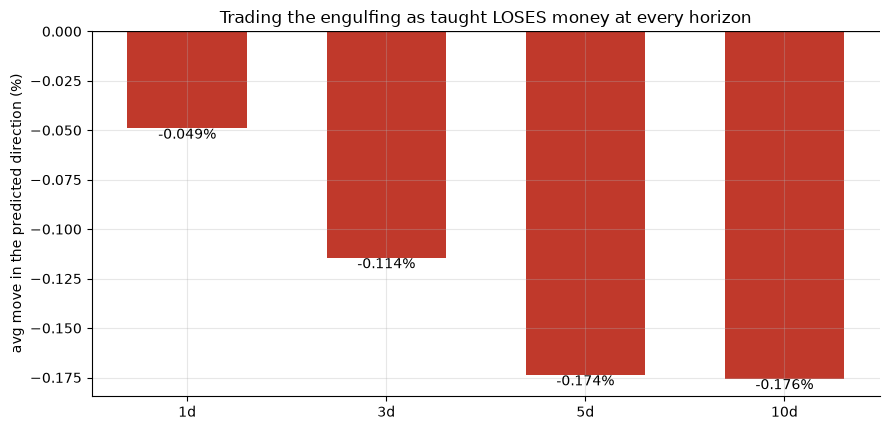

signed mean by horizon: [-0.049, -0.114, -0.174, -0.176]


In [2]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    means = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
else:
    means = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar([f'{h}d' for h in hs], means, color=RED, width=.6)
for i,v in enumerate(means): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.9)
ax.set_ylabel('avg move in the predicted direction (%)')
ax.set_title('Trading the engulfing as taught LOSES money at every horizon')
plt.tight_layout(); plt.show()
print('signed mean by horizon:', [round(v,3) for v in means])

Every bar is **below zero**. Trading the pattern as the book says — long the bullish, short the bearish — loses **-0.049%** the next day and gets *worse* with horizon (**-0.174%** at 5 days). The reversal doesn't just fail to show up; the price tends to go the **other way**.

**Why?** Split the trade into its two legs — bullish (the long) and bearish (the short) — and the culprit jumps out.

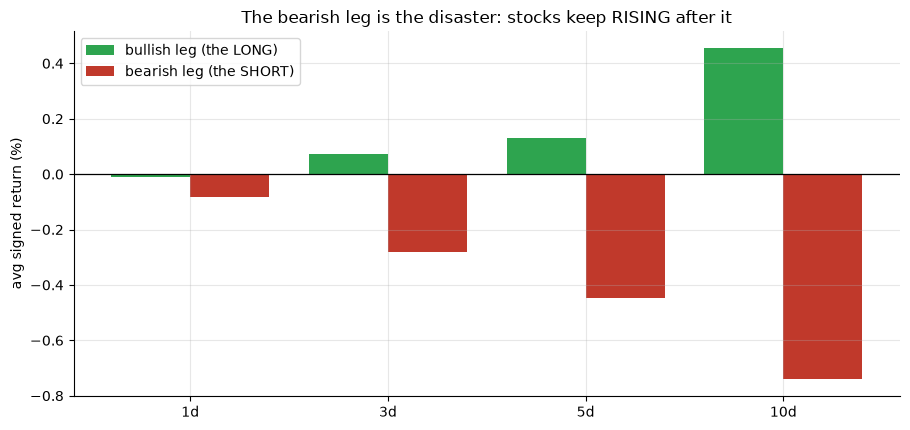

bull leg: [np.float64(-0.011), np.float64(0.072), np.float64(0.13), np.float64(0.456)]
bear leg: [np.float64(-0.083), np.float64(-0.281), np.float64(-0.446), np.float64(-0.741)]


In [3]:
if HAVE_REAL:
    bull, bear = [], []
    for h in hs:
        ev = st.collect_events(PANEL, h)
        bull.append(ev[ev['dir']>0]['signed_ret'].mean()*100)
        bear.append(ev[ev['dir']<0]['signed_ret'].mean()*100)
else:
    bull = [R['bull'][h][0] for h in hs]; bear = [R['bear'][h][0] for h in hs]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, bull, .4, color=GREEN, label='bullish leg (the LONG)')
ax.bar(x+.2, bear, .4, color=RED, label='bearish leg (the SHORT)')
ax.axhline(0, c='k', lw=.9); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('avg signed return (%)')
ax.set_title('The bearish leg is the disaster: stocks keep RISING after it')
ax.legend(); plt.tight_layout(); plt.show()
print('bull leg:', [round(v,3) for v in bull]); print('bear leg:', [round(v,3) for v in bear])

There it is. After a **bearish** engulfing — supposedly a top — the stock keeps **climbing**, so the short bleeds (**-0.446%** at 5 days). The **bullish** leg looks green over a week or two... but hold that thought.

**The bullish trap.** That green bullish leg isn't a reversal — it's the market's normal upward drift. Compare the bullish-leg return to what you'd earn buying a **random** day and holding the same number of days.

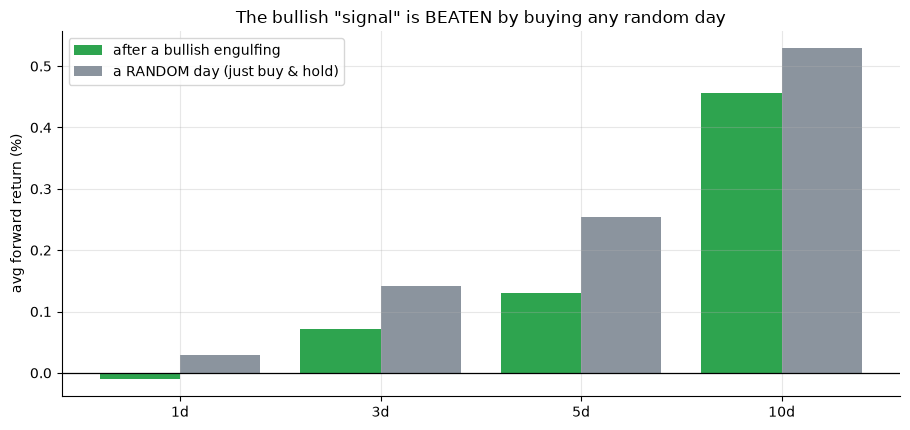

bullish 10d: 0.456 vs random 10d: 0.53


In [4]:
if HAVE_REAL:
    bull = []; base = []
    for h in hs:
        ev = st.collect_events(PANEL, h)
        bull.append(ev[ev['dir']>0]['signed_ret'].mean()*100)
        base.append(st.unconditional_base(PANEL, h).mean()*100)
else:
    bull = [R['bull'][h][0] for h in hs]; base = [R['h1'][3], R['h3'][3], R['h5'][3], R['h10'][3]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, bull, .4, color=GREEN, label='after a bullish engulfing')
ax.bar(x+.2, base, .4, color=GREY, label='a RANDOM day (just buy & hold)')
ax.axhline(0, c='k', lw=.9); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('avg forward return (%)')
ax.set_title('The bullish "signal" is BEATEN by buying any random day')
ax.legend(); plt.tight_layout(); plt.show()
print('bullish 10d:', round(bull[-1],3), 'vs random 10d:', round(base[-1],3))

At 10 days the bullish engulfing earns **+0.456%** — but a **random** day earns **+0.530%**. The candle does *worse* than buying nothing in particular. So even the half that looks good is just beta you'd have collected anyway.

## 5 · The verdict

- **Signal — None.** Traded as taught, the engulfing loses money at every horizon (**-0.049%** the next day) with a **48%** win-rate. No reversal — if anything, the *reverse* of one.
- **Tradability — Mirage.** It's negative **before costs**, so there's nothing to trade. Charging the round trip just makes it worse.
- **A reliable reversal? — Busted.** The bearish leg keeps rising; the bullish leg is just the market drifting up. The famous pattern doesn't call turns.

## 6 · Could you actually trade it? — there's nothing to trade

Usually this beat is where a real signal dies on costs. Here it's already dead before we get there: the gross edge is **negative**, so costs only deepen the hole. Gross vs net, the trade as taught:

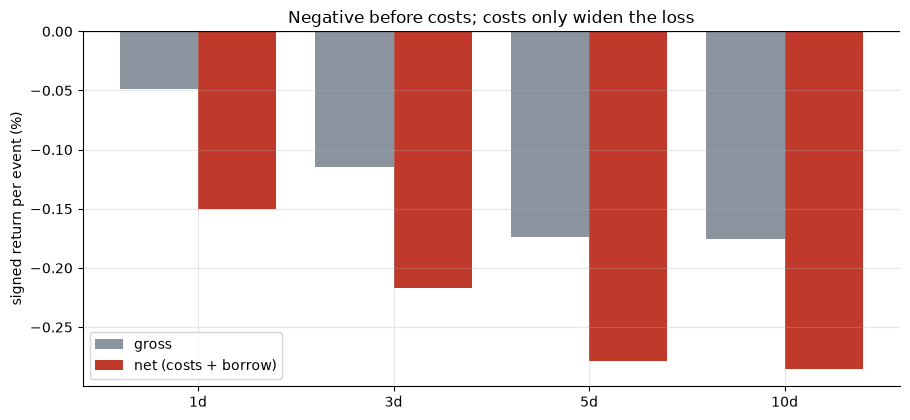

net by horizon: [-0.15, -0.217, -0.279, -0.285]


In [5]:
if HAVE_REAL:
    g = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
    nv = [st.summarize(PANEL, h, placebo=False)['net']*100 for h in hs]
else:
    g = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    nv = [R['h1'][8], R['h3'][8], R['h5'][8], R['h10'][8]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, g, .4, color=GREY, label='gross')
ax.bar(x+.2, nv, .4, color=RED, label='net (costs + borrow)')
ax.axhline(0, c='k', lw=.9); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('signed return per event (%)'); ax.set_title('Negative before costs; costs only widen the loss')
ax.legend(); plt.tight_layout(); plt.show()
print('net by horizon:', [round(v,3) for v in nv])

Net of a realistic round trip plus borrow on the shorts, the loss widens to **-0.150%** (1d) … **-0.285%** (10d). There is no capacity question to ask — you can't scale a negative number into a profit.

## 7 · Going further 🚪

- **Is the harness just broken?** No — the quants notebook plants a *fake* reversal into synthetic data and the exact same code lights up at *t* = 39. The test would see a real reversal; the tape just doesn't have one.
- **What about small-caps / crypto / other markets?** Candlestick studies (Marshall, Young & Rose 2006) mostly find nothing across markets too — fork the basket and check.
- **What about combining it with a real signal?** The engulfing might add nothing, or might even subtract (it anti-predicts here). Try it as a *filter* on a known edge and measure.

*Think the engulfing predicts turns on some universe? Show the **signed** next-day return landing above zero with an honest *t* — then we'll talk.*